In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import os

print(" MyDrive:")
print(os.listdir('/content/drive/MyDrive'))

print("\n" + "="*50)
print("   Brain_Tumor  brain tumor،   :")

 MyDrive:
['algebra.pdf', 'Integration and Applicatioins (1).pdf', 'Exercise Solutions.pdf', 'advanced Model answer1 (1).pdf', 'Integration and Applicatioins.pdf', 'advanced Model answer1.pdf', 'All Problems.pdf', '7thExam with solu-1.pdf', 'python.pdf', '4726272.pdf', 'Classroom', 'OOP Summary F-2 (1).pdf', 'CamScanner 03-29-2024 23.39.pdf', 'Saved from Chrome', '20250525_130810.mp4', 'project.data science', 'Copy of sheet 6..pdf', 'Copy of sheet 5.pdf', 'Colab Notebooks', 'made the assignment.gsheet', 'تحديد حدود قياس جودة المياه.gsheet', 'Brain_Tumor']

   Brain_Tumor  brain tumor،   :


In [7]:
import zipfile
import os
from google.colab import drive

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Brain_Tumor/archive.zip'
extract_path = '/content/brain_tumor_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("dataset decoded!")
print(os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset decoded!
['Training', 'Testing']


In [8]:
import os

base_path = '/content/brain_tumor_data'

print("Training classes:")
print(os.listdir(base_path + '/Training'))

print("\nTesting classes:")
print(os.listdir(base_path + '/Testing'))

Training classes:
['notumor', 'meningioma', 'pituitary', 'glioma']

Testing classes:
['notumor', 'meningioma', 'pituitary', 'glioma']


In [9]:
import os

train_path = '/content/brain_tumor_data/Training'
test_path = '/content/brain_tumor_data/Testing'

print("Training Classes:", os.listdir(train_path))
print("Testing Classes:", os.listdir(test_path))
print("\nNumber of training images per class:")
for cls in os.listdir(train_path):
    print(cls, ":", len(os.listdir(os.path.join(train_path, cls))))

Training Classes: ['notumor', 'meningioma', 'pituitary', 'glioma']
Testing Classes: ['notumor', 'meningioma', 'pituitary', 'glioma']

Number of training images per class:
notumor : 1400
meningioma : 1400
pituitary : 1400
glioma : 1400


In [27]:
# @title
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_data/Training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    '/content/brain_tumor_data/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Data Augmentation applied successfully!")
print("Classes:", train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Data Augmentation applied successfully!
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


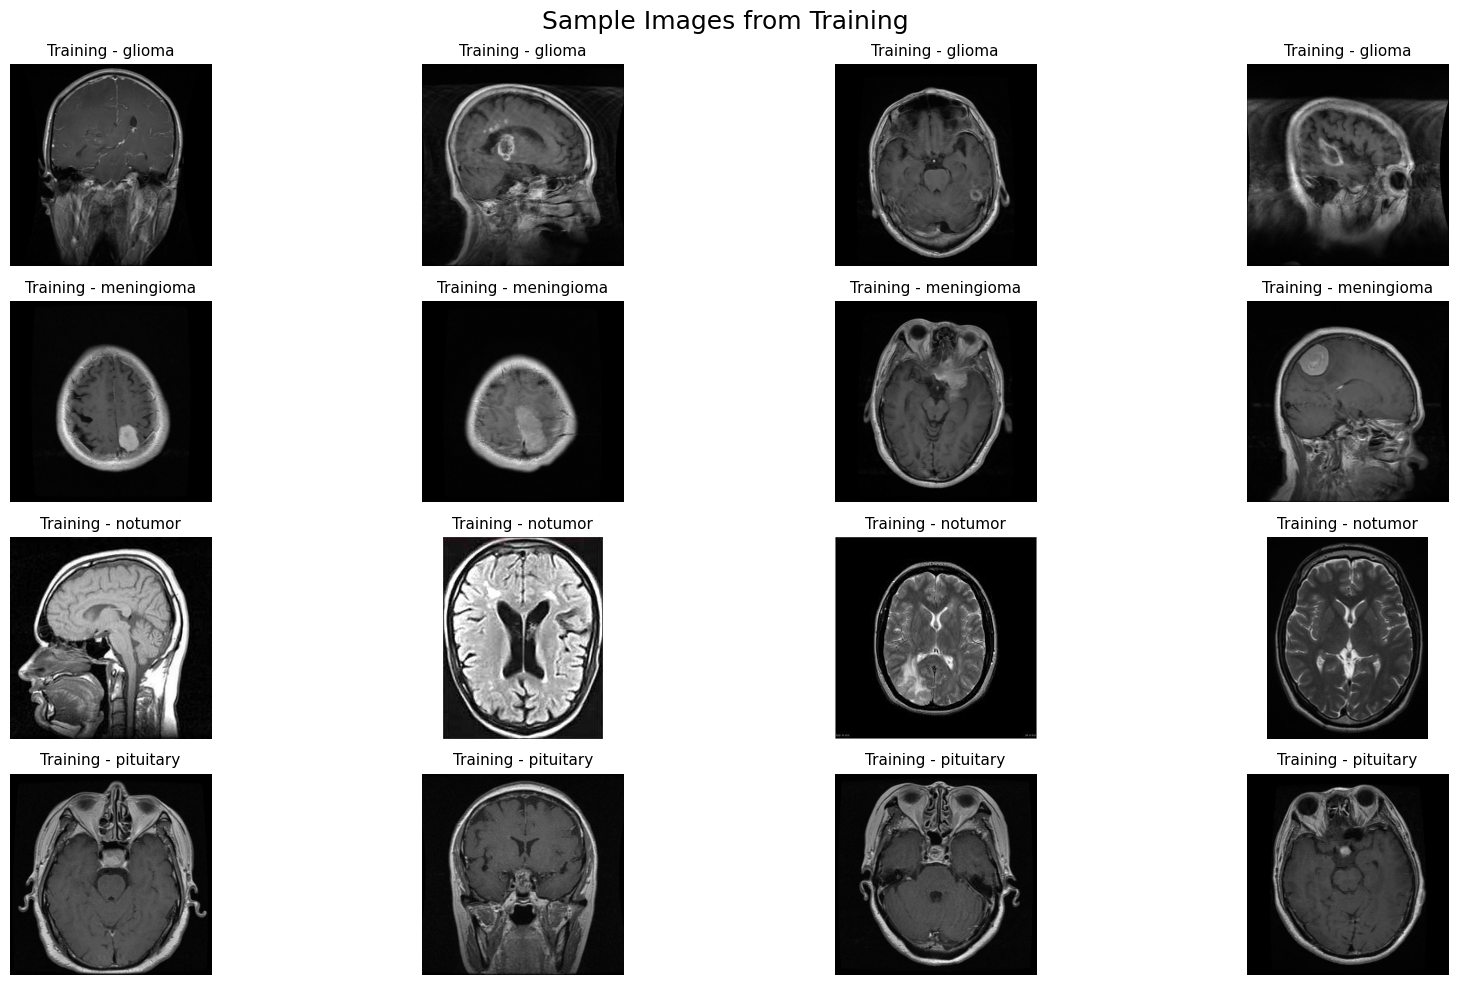

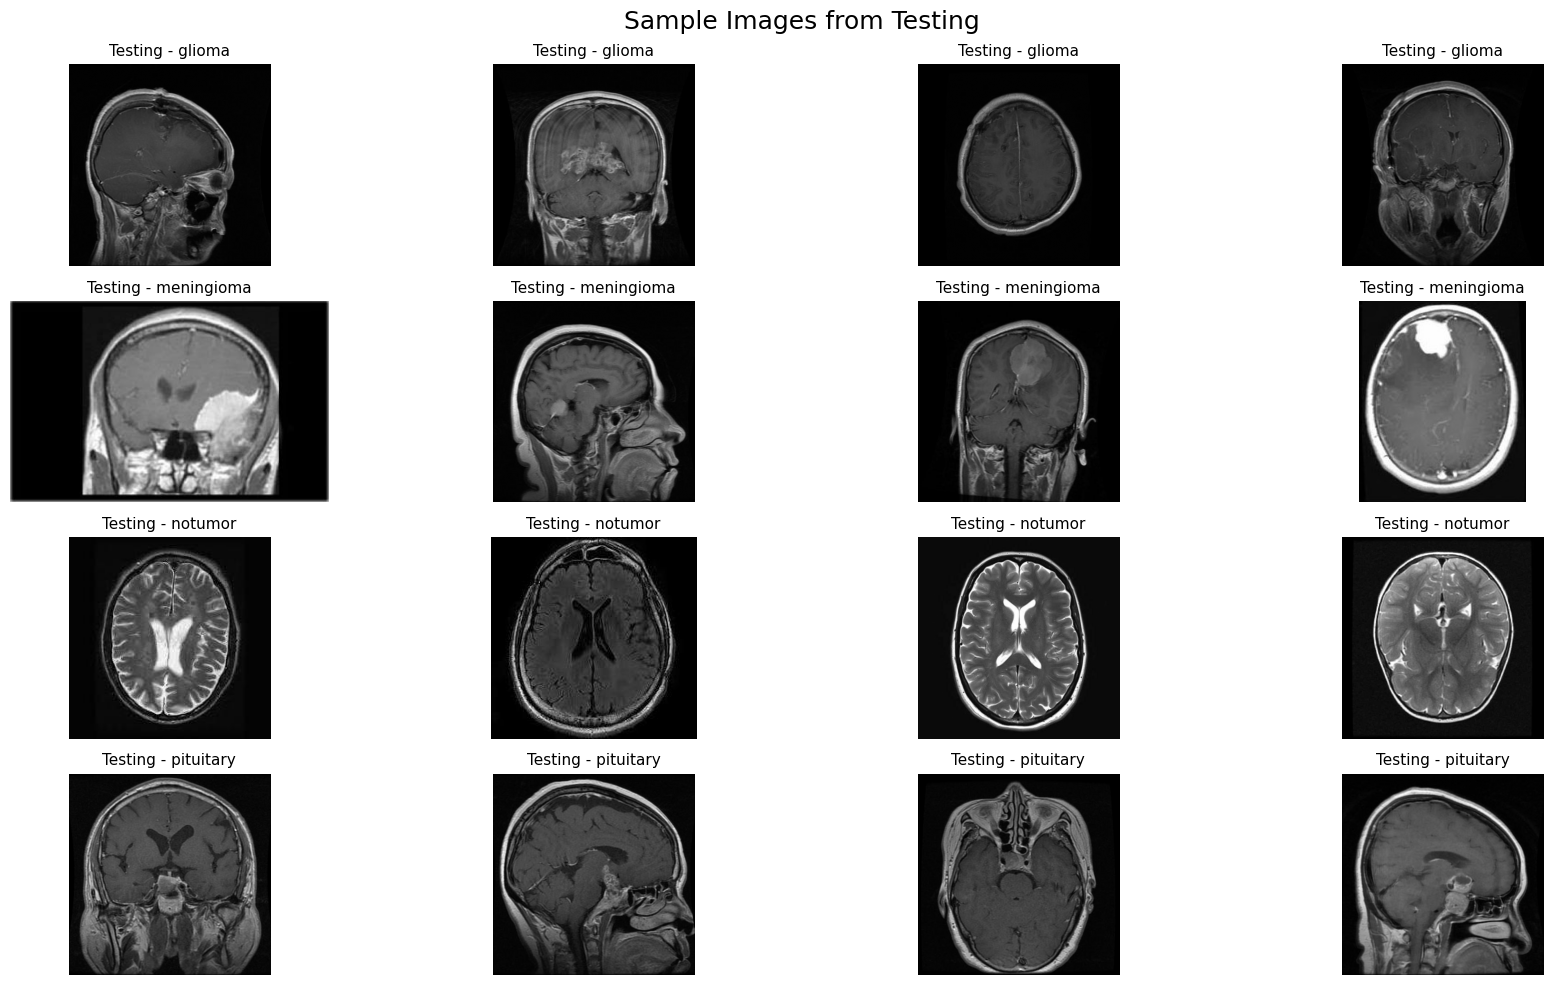

In [21]:
import matplotlib.pyplot as plt
import os
from PIL import Image

train_path = '/content/brain_tumor_data/Training'
test_path = '/content/brain_tumor_data/Testing'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']


plt.figure(figsize=(18, 10))
plt.suptitle("Sample Images from Training ", fontsize=18)

for row, cls in enumerate(classes):
    class_path = os.path.join(train_path, cls)
    image_names = os.listdir(class_path)[:4]

    for col, img_name in enumerate(image_names):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(4, 4, row*4 + col + 1)
        plt.imshow(img, cmap='gray' if img.mode == 'L' else None)
        plt.title(f"Training - {cls}", fontsize=11)
        plt.axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 10))
plt.suptitle("Sample Images from Testing ", fontsize=18)

for row, cls in enumerate(classes):
    class_path = os.path.join(test_path, cls)
    image_names = os.listdir(class_path)[:4]

    for col, img_name in enumerate(image_names):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(4, 4, row*4 + col + 1)
        plt.imshow(img, cmap='gray' if img.mode == 'L' else None)
        plt.title(f"Testing - {cls}", fontsize=11)
        plt.axis('off')

plt.tight_layout()
plt.show()